In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import qmc
import pickle

In [6]:
latlong = pd.read_excel('/scratch/e1372a04/CA_2025/data/latin/latlong_ex.xlsx')
latlong_dropped = latlong.drop(columns=['OBJECTID'])
#latlong_round = latlong_dropped.round({'x': 3, 'y': 3})

In [7]:
latlong_dropped_df = latlong_dropped[latlong_dropped['SIG_ENG_NM'] == 'Yanggu-gun']
latlong_dropped_df

,x,y,SIG_ENG_NM
122150,127.988876,38.009546,Yanggu-gun
122151,127.997209,38.009546,Yanggu-gun
122152,127.938876,38.017879,Yanggu-gun
122153,127.988876,38.017879,Yanggu-gun
122154,127.997209,38.017879,Yanggu-gun
...,...,...,...
123092,128.122209,38.317879,Yanggu-gun
123093,128.130542,38.317879,Yanggu-gun
123094,128.138876,38.317879,Yanggu-gun
123095,128.147209,38.317879,Yanggu-gun


In [8]:
len(latlong_dropped_df)

947

In [9]:
print(latlong_dropped_df.iloc[:, 0].mean())
print(latlong_dropped_df.iloc[:, 1].mean())

127.99975218159874
38.17360761938616


In [10]:
# 멕센트

x_mean_value = latlong_dropped_df.iloc[:, 0].mean()
y_mean_value = latlong_dropped_df.iloc[:, 1].mean()
print(x_mean_value+0.085)
print(x_mean_value-0.085)
print(y_mean_value+0.085)
print(y_mean_value-0.085)

latlong_cut_df = latlong_dropped.copy()

latlong_cut_df = latlong_cut_df[latlong_cut_df['x']<128.08]
latlong_cut_df = latlong_cut_df[latlong_cut_df['x']>127.91]
latlong_cut_df = latlong_cut_df[latlong_cut_df['y']<38.25]
latlong_cut_df = latlong_cut_df[latlong_cut_df['y']>38.08]

print(len(latlong_cut_df['x']))

128.08475218159873
127.91475218159874
38.25860761938616
38.08860761938616
400


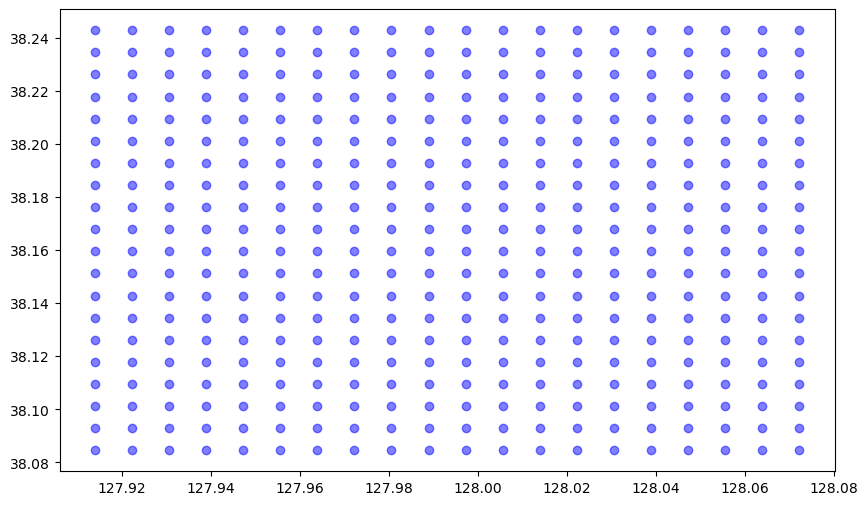

In [11]:
# 데이터 시각화
plt.figure(figsize=(10, 6))
plt.scatter(latlong_cut_df['x'], latlong_cut_df['y'], color='blue', label='All Data', alpha=0.5)

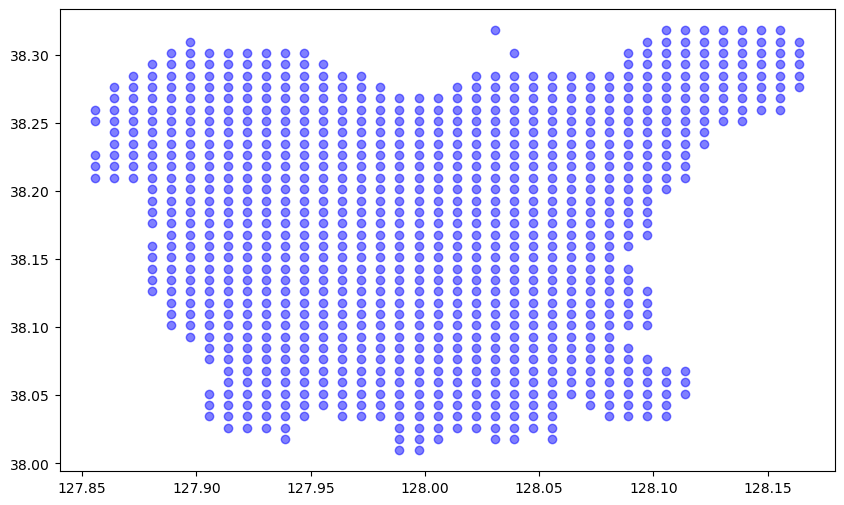

In [12]:
# 데이터 시각화
plt.figure(figsize=(10, 6))
plt.scatter(latlong_dropped_df['x'], latlong_dropped_df['y'], color='blue', label='All Data', alpha=0.5)

In [13]:
latlong_dropped.loc[(latlong_dropped['SIG_ENG_NM'] == 'Gwangju-si') & (latlong_dropped['y'] <= 36.0), 'SIG_ENG_NM'] = 'Gwangju-si1'
latlong_dropped.loc[(latlong_dropped['SIG_ENG_NM'] == 'Gwangju-si') & (latlong_dropped['y'] > 36.0), 'SIG_ENG_NM'] = 'Gwangju-si2'
latlong_dropped.loc[(latlong_dropped['SIG_ENG_NM'] == 'Goseong-gun') & (latlong_dropped['y'] <= 37.0), 'SIG_ENG_NM'] = 'Goseong-gun1'
latlong_dropped.loc[(latlong_dropped['SIG_ENG_NM'] == 'Goseong-gun') & (latlong_dropped['y'] > 37.0), 'SIG_ENG_NM'] = 'Goseong-gun2'
latlong_dropped.loc[(latlong_dropped['SIG_ENG_NM'] == 'Inje-gun') & (latlong_dropped['y'] > 37.0), 'SIG_ENG_NM'] = 'Inje-gun1'

# 결과 출력
latlong_dropped_df = latlong_dropped[latlong_dropped['SIG_ENG_NM'] == 'Inje-gun1']
latlong_dropped_df

,x,y,SIG_ENG_NM
70001,128.205542,37.817879,Inje-gun1
70002,128.213876,37.817879,Inje-gun1
70003,128.197209,37.826212,Inje-gun1
70004,128.205542,37.826212,Inje-gun1
70005,128.213876,37.826212,Inje-gun1
...,...,...,...
72378,128.238876,38.367879,Inje-gun1
72379,128.247209,38.367879,Inje-gun1
72380,128.255542,38.367879,Inje-gun1
72381,128.263876,38.367879,Inje-gun1


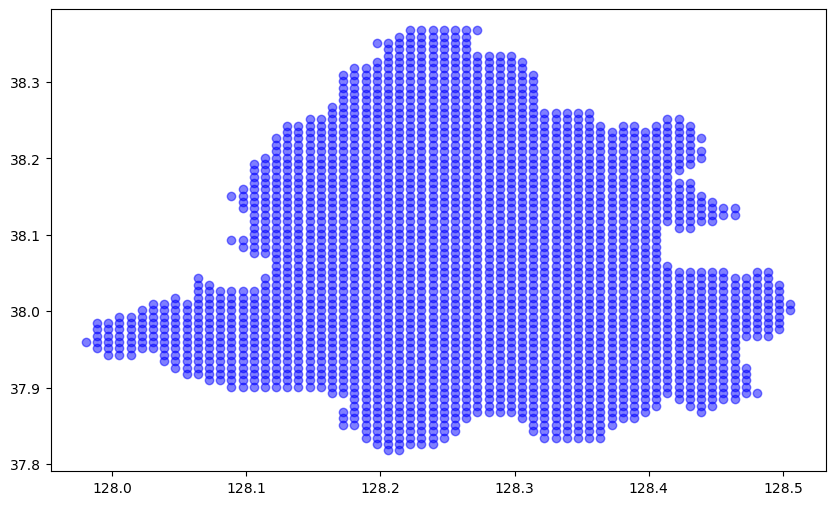

In [14]:
# 데이터 시각화
plt.figure(figsize=(10, 6))
plt.scatter(latlong_dropped_df['x'], latlong_dropped_df['y'], color='blue', label='All Data', alpha=0.5)

In [16]:
#예측할 종이름
species = 'TES_ensemble'

In [18]:
# 지역별로 위도 경도 분리하기
#latlong = pd.read_excel('C:/Users/LG/Documents/maxent/외래생물확산/latlong_ex.xlsx')
#latlong_dropped = latlong.drop(columns=['OBJECTID'])
latlong_round = latlong_dropped.round({'x': 3, 'y': 3})

maxents = ["ssp126_2030.csv", "ssp126_2050.csv", "ssp126_2070.csv", "ssp126_2090.csv",
           "ssp245_2030.csv", "ssp245_2050.csv", "ssp245_2070.csv", "ssp245_2090.csv",
           "ssp585_2030.csv", "ssp585_2050.csv", "ssp585_2070.csv", "ssp585_2090.csv"]
maxent_datas = {}
maxent_datas_sampling = {}

np.random.seed(0)  # 랜덤 시드 설정 (재현 가능성을 위해)
num_samples = 400
# qmc 모듈을 사용하여 라틴 하이퍼 큐브 샘플링 수행
sampler = qmc.LatinHypercube(d=2)  # d는 x와 y의 차원
sample_indices = sampler.random(n=num_samples)  # 샘플링 수행

for maxent in maxents:
    maxent0 = pd.read_csv("/scratch/e1372a04/CA_2025/data/midpoint/"+species+"/"+maxent)
    #maxent_dropped = maxent0.drop(columns=['Unnamed: 0'])
    maxent_round = maxent0.round({'x': 3, 'y': 3})
    finish = pd.merge(maxent_round, latlong_round, how='inner', left_on = ['x','y'], right_on=['x','y'])
    local_values = finish['SIG_ENG_NM'].drop_duplicates()
    local_values_list = local_values.tolist()
    
    maxent_data = {}
    maxent_data_sampling = {}
    for local_value in local_values_list:
        try:
            filtered_df = finish[finish['SIG_ENG_NM'] == local_value]
            maxent_data[local_value] = filtered_df
            
            sample_indices0 = (sample_indices * len(filtered_df)).astype(int)
            sample_indices0 = sample_indices0[:, 0]
            sampled_data = filtered_df.iloc[sample_indices0]
            maxent_data_sampling[local_value] = sampled_data
            
        except Exception as e:
            print(local_value)
    
    maxent_datas[maxent[0:11]] = maxent_data
    maxent_datas_sampling[maxent[0:11]] = maxent_data_sampling
    
with open("/scratch/e1372a04/CA_2025/data/latin/TES_ensemble/"+"all"+".pkl", 'wb') as file:
    pickle.dump(maxent_datas, file)
with open("/scratch/e1372a04/CA_2025/data/latin/TES_ensemble/"+"sampling"+".pkl", 'wb') as file:
    pickle.dump(maxent_datas_sampling, file)
local_values.to_csv("/scratch/e1372a04/CA_2025/data/latin/local_index.csv", index=False)

In [19]:
maxent_datas_sampling['ssp126_2030']['Inje-gun1']
#'/scratch/e1372a04/C_A/4ch/p1'

,x,y,ssp126_2030,SIG_ENG_NM
11052,128.297,37.901,0.067411,Inje-gun1
2797,128.306,38.210,0.012084,Inje-gun1
4535,128.122,38.135,0.022328,Inje-gun1
10555,128.397,37.918,0.011253,Inje-gun1
8025,128.264,38.001,0.163207,Inje-gun1
...,...,...,...,...
5817,128.264,38.085,0.011714,Inje-gun1
8696,127.989,37.976,0.054361,Inje-gun1
497,128.281,38.335,0.010696,Inje-gun1
4158,128.272,38.151,0.014149,Inje-gun1


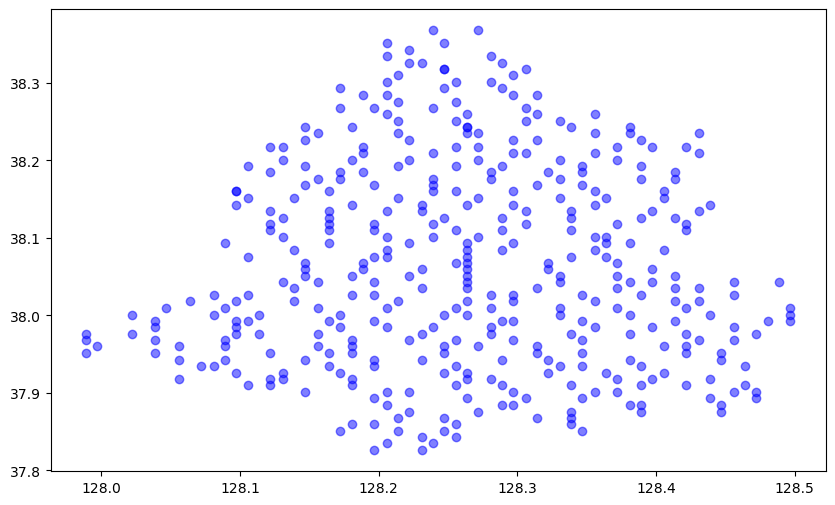

In [20]:
# 데이터 시각화
plt.figure(figsize=(10, 6))
aa = maxent_datas_sampling['ssp126_2030']['Inje-gun1']
plt.scatter(aa['x'], aa['y'], color='blue', label='All Data', alpha=0.5)

In [ ]:
data = {'Jindo-gun': [126.13, 126.36, 34.36, 34.55], 
        'Seogwipo-si' : [126.495, 126.67, 33.24, 33.405],
        'Jeju-si' : [126.44, 126.61, 33.32, 33.49],
        'Goseong-gun1' : [128.185, 128.35, 34.96, 35.13],
        'Goseong-gun2' : [128.31, 128.48, 38.23, 38.4],
        'Inje-gun1' : [128.18, 128.34, 37.98, 38.15],
        'Cheorwon-gun' : [127.29, 127.46, 38.13, 38.30],
        'Yanggu-gun' : [127.91, 128.08, 38.08, 38.25],
        'Hwacheon-gun' : [127.60, 127.77, 38.055, 38.22],
        'Yeoncheon-gun' : [127.0, 127.17, 38.005, 38.17], #
        'Sokcho-si' : [128.385, 128.55, 38.03, 38.2],
        'Pocheon-si' : [127.17, 127.335, 37.88, 38.05],
        'Yangyang-gun' : [128.5, 128.67, 37.92, 38.085],
        'Chuncheon-si' : [127.65, 127.82, 37.805, 37.97],
        'Gapyeong-gun' : [127.37, 127.535, 37.73, 37.90],
        'Paju-si' : [126.72, 126.885, 37.755, 37.92],
        'Yangju-si' : [126.92, 127.085, 37.72, 37.885],
        'Hongcheon-gun' : [127.985, 128.15, 37.655, 37.82],
        'Gangneung-si' : [128.725, 128.89, 37.56, 37.73],
        'Ganghwa-gun' : [126.35, 126.53, 37.59, 37.81],#
        'Pyeongchang-gun' : [128.39, 128.56, 37.47, 37.635],
        'Gimpo-si' : [126.5, 126.70, 37.59, 37.77],
        'Uijeongbu-si' : [126.985, 127.15, 37.665, 37.82],
        'Namyangju-si' : [127.16, 127.33, 37.58, 37.75],
        'Goyang-si' : [126.75, 126.92, 37.58, 37.755],
        'Seoul-si' : [126.92, 127.085, 37.47, 37.64],
        'Hoengseong-gun' : [127.985, 128.15, 37.42, 37.585],
        'Yangpyeong-gun' : [127.485, 127.65, 37.43, 37.60],
        'Incheon-si' : [126.6, 126.8, 37.4, 37.6],
        'Guri-si' : [127.04, 127.21, 37.52, 37.685],#
        'Donghae-si' : [128.93, 129.11, 37.42, 37.58],
        'Hanam-si' : [127.125, 127.29, 37.445, 37.61],
        'Jeongseon-gun' : [128.65, 128.82, 37.295, 37.46],
        'Bucheon-si' : [126.7, 126.87, 37.425, 37.59],
        'Gwangju-si1' : [127.215, 127.385, 37.32, 37.485],
        'Gwangju-si2' : [126.74, 126.91, 35.075, 35.24],
        'Wonju-si' : [127.835, 128, 37.22, 37.385],
        'Gwangmyeong-si' : [126.79, 126.96, 37.36, 37.53],
        'Siheung-si' : [126.7, 126.88, 37.28, 37.47],
        'Seongnam-si' : [127.035, 127.2, 37.32, 37.485],#
        'Samcheok-si' : [129.035, 129.2, 37.18, 37.35],
        'Gwacheon-si' : [126.92, 127.085, 37.355, 37.52],
        'Anyang-si' : [126.835, 127, 37.32, 37.485],
        'Yeoju-si' : [127.535, 127.7, 37.22, 37.385],
        'Uiwang-si' : [126.835, 127, 37.28, 37.45],
        'Yeongwol-gun' : [128.42, 128.585, 37.12, 37.285],
        'Gunpo-si' : [126.86, 127.025, 37.265, 37.43],
        'Yongin-si' : [127.14, 127.31, 37.145, 37.31],
        'Icheon-si' : [127.4, 127.57, 37.125, 37.29],
        'Suwon-si' : [126.925, 127.09, 37.205, 37.37],#
        'Taebaek-si' : [128.885, 129.05, 37.08, 37.25],
        'Hwaseong-si' : [126.81, 126.975, 37.08, 37.255],
        'Jecheon-si' : [128.1, 128.27, 37.03, 37.2],
        'Chungju-si' : [127.82, 127.985, 36.93, 37.10],
        'Osan-si' : [126.965, 127.135, 37.075, 37.24],
        'Anseong-si' : [127.22, 127.385, 36.955, 37.12],
        'Eumseong-gun' : [127.525, 127.69, 36.895, 37.06],
        'Danyang-gun' : [128.29, 128.46, 36.92, 37.085],
        'Uljin-gun' : [129.235, 129.40, 36.82, 36.985],
        'Pyeongtaek-si' : [126.9, 127.065, 36.9, 37.085],#
        'Bonghwa-gun' : [128.825, 128.99, 36.855, 37.02],
        'Dangjin-si' : [126.56, 126.73, 36.80, 36.98],
        'Yeongju-si' : [128.52, 129.685, 36.78, 36.95],
        'Seosan-si' : [126.38, 126.57, 36.62, 36.805],
        'Jincheon-gun' : [127.34, 127.51, 36.78, 36.95],
        'Cheonan-si' : [127.135, 127.3, 36.755, 36.92],
        'Taean-gun' : [126.21, 126.39, 36.6, 36.9],
        'Goesan-gun' : [127.735, 127.9, 36.675, 36.84],
        'Asan-si' : [126.89, 127.065, 36.72, 36.885],
        'Yeongyang-gun' : [129.05, 129.22, 36.62, 36.785],#
        'Mungyeong-si' : [128.05, 128.22, 36.605, 36.77],
        'Jeungpyeong-gun' : [127.52, 127.685, 36.675, 36.84],
        'Yecheon-gun' : [128.385, 128.55, 36.57, 36.735],
        'Andong-si' : [128.705, 128.87, 36.505, 36.67],
        'Yesan-gun' : [126.705, 126.87, 36.58, 36.75],
        'Cheongju-si' : [127.42, 127.585, 36.53, 36.7],
        'Sejong-si' : [127.17, 127.335, 36.48, 36.65],
        'Hongseong-gun' : [126.53, 126.695, 36.47, 36.65],
        'Gongju-si' : [126.985, 127.15, 36.405, 36.57],
        'Yeongdeok-gun' : [129.2, 129.37, 36.4, 36.57],#
        'Sangju-si' : [127.985, 128.15, 36.345, 36.51],
        'Boeun-gun' : [127.64, 127.81, 36.405, 36.57],
        'cheongsong-gun' : [128.96, 129.125, 36.27, 36.435],
        'Cheongyang-gun' : [126.775, 126.94, 36.355, 36.52],
        'Uiseong-gun' : [128.525, 128.69, 36.275, 36.44],
        'Boryeong-si' : [126.52, 126.70, 36.25, 36.42],
        'Daejeon-si' : [127.32, 127.485, 36.27, 36.435],
        'Okcheon-gun' : [127.57, 127.735, 36.23, 36.4],
        'Buyeo-gun' : [126.77, 126.935, 36.155, 36.32],
        'Gumi-si' : [128.27, 128.435, 36.12, 36.285],#
        'Gyeryong-si' : [127.145, 127.31, 36.205, 36.37],
        'Nonsan-si' : [127.07, 127.235, 36.105, 36.27],
        'Pohang-si' : [129.185, 129.35, 36.03, 36.20],
        'Gunwi-gun' : [128.55, 128.72, 36.08, 36.25],
        'Yeongdong-gun' : [127.725, 127.89, 36.075, 36.24],
        'Geumsan-gun' : [127.385, 127.55, 36.02, 36.185],
        'Gimcheon-si' : [127.99, 128.16, 35.975, 36.14],
        'Seocheon-gun' : [126.6, 126.82, 36.02, 36.17],
        'Yeongcheon-si' : [128.85, 129.02, 35.925, 36.09],
        'Iksan-si' : [126.89, 127.06, 35.93, 36.1],#
        'Wanju-gun' : [127.15, 127.32, 35.9, 36.07],
        'Gunsan-si' : [126.6, 126.84, 35.87, 36.04],
        'Chilgok-gun' : [128.375, 128.54, 35.925, 36.09],
        'Gyeongju-si' : [129.145, 129.31, 35.745, 35.91],
        'Muju-gun' : [127.625, 127.79, 35.845, 36.01],
        'Seongju-gun' : [128.155, 128.32, 35.82, 35.985],
        'Jinan-gun' : [127.335, 127.5, 35.73, 35.9],
        'Daegu-si' : [128.535, 128.7, 35.805, 35.97],
        'Gyeongsan-si' : [128.72, 128.885, 35.755, 35.92],
        'Dalseong-gun' : [128.42, 128.585, 35.68, 35.85],#
        'Gimje-si' : [126.8, 127, 35.76, 35.905],
        'Geochang-gun' : [127.82, 127.985, 35.655, 35.82],
        'Jeonju-si' : [127.025, 127.19, 35.73, 35.9],
        'Goryeong-gun' : [128.22, 128.385, 35.645, 35.81],
        'Cheongdo-gun' : [128.695, 128.86, 35.575, 35.74],
        'Jangsu-gun' : [127.455, 127.62, 35.57, 35.735],
        'Hapcheon-gun' : [128.055, 128.22, 35.57, 35.735],
        'Buan-gun' : [126.55, 126.75, 35.6, 35.76],
        'Hamyang-gun' : [127.635, 127.8, 35.47, 35.635],
        'Imsil-gun' : [127.145, 127.31, 35.505, 35.67],#
        'Jeongeup-si' : [126.82, 126.985, 35.52, 35.685],
        'Ulju-gun' : [129.095, 129.26, 35.47, 35.635],
        'Changnyeong-gun' : [128.405, 128.57, 35.42, 35.585],
        'Ulsan-si' : [129.28, 129.45, 35.46, 35.65],
        'Miryang-si' : [128.705, 128.87, 35.415, 35.58],
        'Gochang-gun' : [126.555, 126.72, 35.325, 35.49],
        'Sancheong-gun' : [127.79, 127.96, 35.275, 35.44],
        'Sunchang-gun' : [127.005, 127.17, 35.345, 35.51],
        'Namwon-si' : [127.355, 127.52, 35.33, 35.5],
        'Yangsan-si' : [128.955, 129.12, 35.32, 35.485],#
        'Uiryeong-gun' : [128.175, 128.34, 35.32, 35.485],
        'Jangseong-gun' : [126.675, 126.84, 35.23, 35.4],
        'Damyang-gun' : [126.92, 127.085, 35.205, 35.37],
        'Yeonggwang-gun' : [126.36, 126.55, 35.2, 35.36],
        'Haman-gun' : [128.34, 128.51, 35.2, 35.37],
        'Changwon-si' : [128.49, 128.69, 35.12, 35.285],
        'Gimhae-si' : [128.755, 128.92, 35.18, 35.35],
        'Gijang-gun' : [129.1, 129.25, 35.2, 35.4],
        'Gurye-gun' : [127.42, 127.585, 35.155, 35.32],
        'Jinji-si' : [128.045, 128.21, 35.12, 35.285],#
        'Gokseong-gun' : [127.175, 127.34, 35.125, 35.29],
        'Hadong-gun' : [127.695, 127.86, 35.045, 35.21],
        'Busan-si' : [128.96, 129.15, 35.05, 35.25],
        'Hampyeong-gun' : [126.475, 126.64, 35.03, 35.02],
        'Hwasun-gun' : [126.96, 127.125, 34.92, 35.085],
        'Suncheon-si' : [127.29, 127.46, 34.92, 35.085],
        'Gwangyang-si' : [127.57, 127.75, 34.95, 35.11],
        'Sacheon-si' : [127.94, 128.135, 34.99, 35.155],
        'Sinan-gun' : [125.8, 126.3, 34.58, 34.93],
        'Muan-gun' : [126.37, 126.56, 34.81, 35.01],#
        'Naju-si' : [126.635, 126.8, 34.895, 35.06],
        'Geoje-si' : [128.5, 128.715, 34.75, 34.97],
        'Boseong-gun' : [27.075, 127.24, 34.765, 34.93],
        'Tongyeong-si' : [128.19, 128.54, 34.6, 34.98],
        'Yeongam-gun' : [126.55, 126.73, 34.71, 34.9],
        'Namhae-gun' : [127.81, 128.06, 34.70, 34.91],
        'Yeosu-si' : [127.56, 127.79, 34.61, 34.84],
        'Jangheung-gun' : [126.85, 127, 34.6, 34.79],
        'Mokpo-si' : [126.3, 126.55, 34.69, 34.92],
        'Goheung-gun' : [127.23, 127.41, 34.51, 34.685],#
        'Gangjin-gun' : [126.68, 126.85, 34.53, 34.72],
        'Haenam-gun' : [126.5, 126.67, 34.45, 34.62],
        'Ansan-si' : [126.52, 126.88, 37.2, 37.39],
        'Dongducheon-si' : [126.985, 127.15, 37.825, 37.99]}
print(df.shape)